In [1]:
!pip install squarify
import squarify

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
transaction = pd.read_csv("/kaggle/input/ieee-fraud-detection/train_transaction.csv")
identity = pd.read_csv("/kaggle/input/ieee-fraud-detection/train_identity.csv")

In [5]:
transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [7]:
print(f"The dataset has about {transaction.shape[0]} rows and {transaction.shape[1]+identity.shape[1]-1} columns")

The dataset has about 590540 rows and 434 columns


In [8]:
transaction.columns.values

array(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain',
       'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
       'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4',
       'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14',
       'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1',
       'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29',
       'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38',
       'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47',
       'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56',
       'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65',
       'V66', 'V6

In [9]:
identity.columns.values

array(['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05',
       'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12',
       'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19',
       'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26',
       'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33',
       'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType',
       'DeviceInfo'], dtype=object)

In [10]:
lis = ['TransactionAmt','dist1','dist2','C1','C2','C3','C4','D1','D2','D3','D4','D5']
print(f"{'Attribute':18} {'Mean':10} {'Median':10} {'Mode':10} {'Std':<14} {'Variance':10}")
for col in lis:
    print(f"{col:18}{round(transaction[col].mean(),3):10}{round(transaction[col].median(),3):10}{round(transaction[col].mode(),3)[0]:10}{round(transaction[col].std(),3):14}{'':3} {round(transaction[col].var(),3):10}")  

Attribute          Mean       Median     Mode       Std            Variance  
TransactionAmt       135.027    68.769      59.0       239.163     57198.712
dist1                118.502       8.0       0.0       371.872    138288.804
dist2                231.855      37.0       7.0       529.053    279897.599
C1                    14.092       1.0       1.0       133.569     17840.683
C2                     15.27       1.0       1.0       154.669     23922.468
C3                     0.006       0.0       0.0         0.151         0.023
C4                     4.092       0.0       0.0        68.848       4740.11
D1                    94.348       3.0       0.0        157.66     24856.797
D2                   169.563      97.0       0.0       177.316     31440.916
D3                    28.343       8.0       0.0        62.385      3891.853
D4                   140.002      26.0       0.0       191.097     36517.977
D5                    42.336      10.0       0.0          89.0      7921.02

In [11]:
lis = ['id_01','id_02','id_03','id_04']
print(f"{'Attribute':18} {'Mean':10} {'Median':10} {'Mode':10} {'Std':<14} {'Variance':10}")
for col in lis:
    print(f"{col:18}{round(identity[col].mean(),3):10}{round(identity[col].median(),3):10}{round(identity[col].mode(),3)[0]:10}{round(identity[col].std(),3):14}{'':3} {round(identity[col].var(),3):10}")  

Attribute          Mean       Median     Mode       Std            Variance  
id_01                -10.171      -5.0      -5.0        14.348       205.864
id_02             174716.585  125800.5    1102.0    159651.817    25488702625.325
id_03                   0.06       0.0       0.0         0.598         0.358
id_04                 -0.059       0.0       0.0         0.701         0.491


In [12]:
sns.set_style('whitegrid')

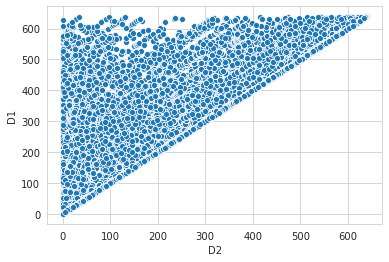

In [13]:
sns.scatterplot(transaction['D2'],transaction['D1'])

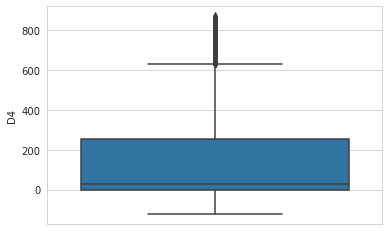

In [14]:
sns.boxplot(transaction['D4'],orient='v')

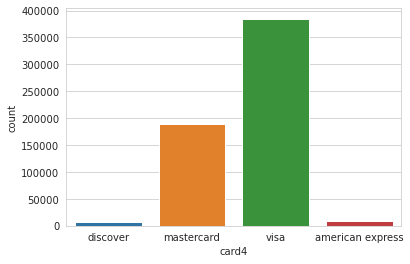

In [15]:
sns.countplot(transaction['card4'])

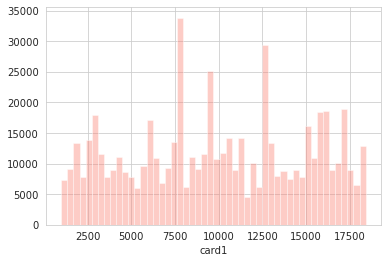

In [16]:
sns.distplot(transaction['card1'],color='salmon',kde=False)

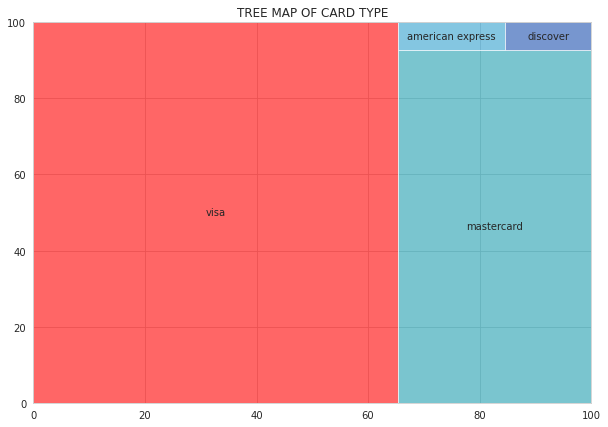

In [17]:
plt.figure(figsize=(10,7))
plt.title('TREE MAP OF CARD TYPE')

color=['red','#219FB0','#32A0CE','#1C51B0']

squarify.plot(sizes=transaction['card4'].value_counts().values,label=transaction['card4'].value_counts().index,color=color, alpha=0.6)

In [18]:
fig = px.parallel_coordinates(transaction[['card2','card3','card5']].sample(10000))
fig.show()